# implementasi kernel SVM

transform training data via mapping function sehingga datanya menjadi linearly separable, lalu train linear SVM model untuk classify data di feature space yg baru. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

## generate dummy data (terpisah non linear): 2 concentric circles

inner circle --> class -1. 
outer circle --> class +1.
terpusat di titik asal (0,0).

- `n_*`: jummlah data points.
- `theta_*` (sudut) = 2π (lingkaran penuh) * random. jadi menghasilkan angka random 0≤θ<2π.
- `r_*` (radius). `1.0` (inner) dan `3.0` (outer) adalah radius dasar; `0.15 atau 0.2 * randn()` noise.
- randn() gaussian; mean 0; bisa +/-. rand() uniform 0≤x<1
- `X_*`: konversi polar ke cartesian --> x=rcos(theta), y=rsin(theta).
- `X = np.vstack()`: vertikal stack --> semua data jadi 1 matrix, shape nya (100, 2)
- `y = np.hstack()`: horizontal stack untuk label. `-np.ones(n_inner)` array [-1,-1,..,-1], `np.ones(n_outer)` array [1,1,..,-1]
- `y.astype(int)`: label dicast ke int karena defalut `np.ones()` itu float


---
- `.fit` = proses training

Shape: (200, 3)


,x1,x2,label
0,-0.714267,0.718406,-1
1,0.909716,-0.291077,-1
2,-0.114448,-1.007283,-1
3,-0.571278,-0.407745,-1
4,0.538432,0.803290,-1
5,0.586736,0.875068,-1
6,1.141226,0.436022,-1
7,0.614997,-0.687271,-1
8,-0.707268,-0.521470,-1
9,-0.240803,-0.892833,-1


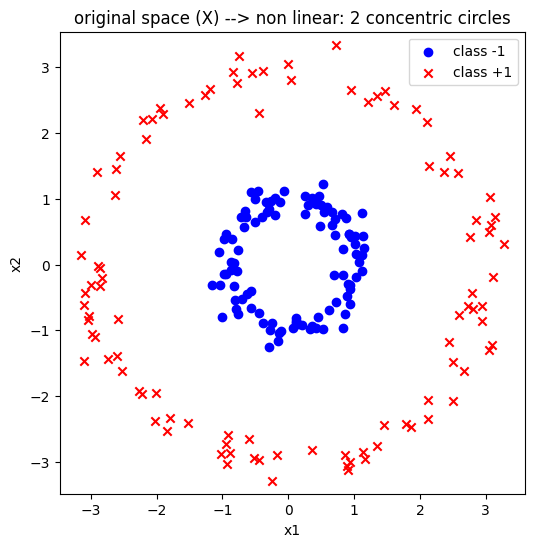

In [23]:
np.random.seed(42)

n_inner = 100
n_outer = 100

theta_inner = 2 * np.pi * np.random.rand(n_inner)
r_inner = 1.0 + 0.15 * np.random.randn(n_inner)

theta_outer = 2 * np.pi * np.random.rand(n_outer)
r_outer = 3.0 + 0.2 * np.random.randn(n_outer)

X_inner = np.c_[r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)]
X_outer = np.c_[r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)]

X = np.vstack([X_inner, X_outer])
y = np.hstack([-np.ones(n_inner), np.ones(n_outer)])

### buat nunjukin dataframe nya
df = pd.DataFrame(X, columns=["x1","x2"])
df["label"] = y.astype(int)
print("Shape:", df.shape)
display(df.head(10))

### plot original space (X)
plt.figure(figsize=(6,6))
plt.scatter(X_inner[:,0], X_inner[:,1], color='blue', label="class -1")
plt.scatter(X_outer[:,0], X_outer[:,1], color='red', marker='x', label="class +1")
plt.title("original space (X) --> non linear: 2 concentric circles")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

###split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## transformasi (2D ke 2D)

- tranformasinya via explicit feature mapping, dengan: mapping function `ϕ(X)=(x1^2,x2^2)` --> kernel function `K(x,z) = ϕ(x)^T ϕ(z) = x1^2 z1^2 + x2^2 z2^2 = (x1z1)^2 + (x2z2)^2`
- kenapa mapping functionnya ϕ(X)=(x1^2,x2^2)? karena bentuk datanya membentuk pola concentric circles. persamaan lingkarannya adalah `r^2 = x1^2 + x2^2`. dengan transfformasi `x1_transformed = x1^2` dan `x2_transformed = x2^2` --> artinya mengubah persamaan non linear `x1^2 + x2^2 = r^2` menjadi persamaan linear lurus `x1_transformed + x2_transformed = r^2`. class +1 dan -1 punya r yg berbeda, sehingga mereka dipisahkan oleh nilai `x1_transformed + x2_transformed` yg berbeda.
- termasuk kernel apa? termasuk polynomial kernel derajat 2, tapi tanpa cross term (2x1x2z1z2). polynomial kernel derajat 2 standar: `K(x,z) = x1^2 z1^2 + 2x1x2z1z2 + x2^2 z2^`.
- kalau pakai cross term, transformasinya malah ke 3D (mapping functionnya `ϕ(X)=(x1^2, √2 x1x2, x2^2)`) (bapaknya nyuruh 2D ke 2D aja).

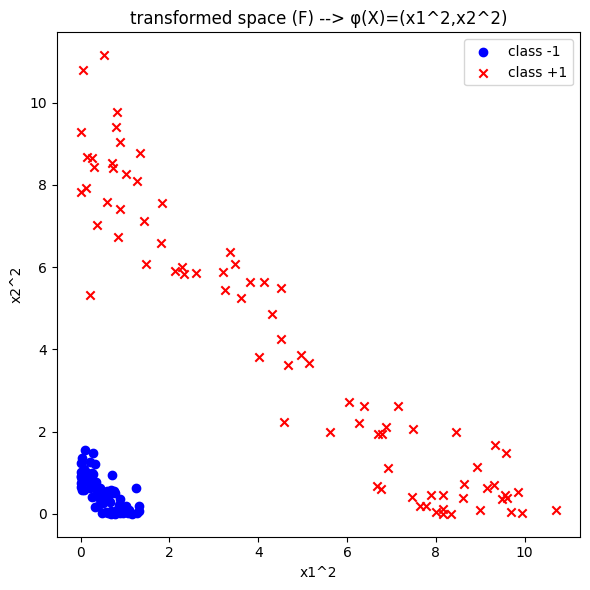

In [27]:
X_train_transformed = X_train ** 2 
X_test_transformed = X_test ** 2

### plot transformed space 
plt.figure(figsize=(6, 6))
plt.scatter(X_train_transformed[y_train==-1, 0], X_train_transformed[y_train==-1, 1], color='blue', label='class -1')
plt.scatter(X_train_transformed[y_train==1, 0], X_train_transformed[y_train==1, 1], color='red', marker='x', label='class +1')
plt.title("transformed space (F) --> φ(X)=(x1^2,x2^2)")
plt.xlabel("x1^2")
plt.ylabel("x2^2")
plt.legend()
plt.tight_layout()
plt.show()

## training

In [47]:
class linearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.w - y[idx] * x_i
                    db = -y[idx]

                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

In [48]:
model = linearSVM()
model.fit(X_train_transformed,y_train)

w = model.w
b = model.b
print("w:", w)
print("b:", b)

margin = 2 / np.linalg.norm(w)
print("margin:", margin)

w: [0.3799029  0.52890261]
b: -1.8929999999999023
margin: 3.071243131020841


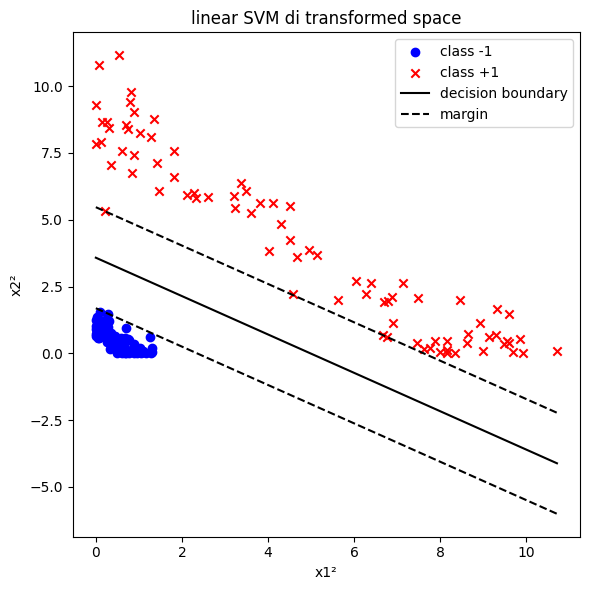

In [49]:
plt.figure(figsize=(6,6))
plt.scatter(X_train_transformed[y_train==-1, 0], X_train_transformed[y_train==-1, 1], color='blue', label='class -1')
plt.scatter(X_train_transformed[y_train==1, 0], X_train_transformed[y_train==1, 1], color='red', marker='x', label='class +1')
x_vals = np.linspace(X_train_transformed[:,0].min(), X_train_transformed[:,0].max(), 100)
y_vals = -(w[0]*x_vals + b) / w[1]
plt.plot(x_vals,y_vals,'k', label='decision boundary')
y_margin_pos = -(w[0]*x_vals + b - 1) / w[1]
y_margin_neg = -(w[0]*x_vals + b + 1) / w[1]
plt.plot(x_vals,y_margin_pos,'k--',label='margin')
plt.plot(x_vals,y_margin_neg,'k--')
plt.xlabel("x1²")
plt.ylabel("x2²")
plt.title("linear SVM di transformed space")
plt.legend()
plt.tight_layout()
plt.show()

## evaluasi

In [50]:
predictions = model.predict(X_test_transformed)

akurasi = np.mean(predictions == y_test) * 100
print(f"akurasi: {akurasi}%")

akurasi: 100.0%
